In [1]:
import matplotlib.pyplot as plt
import numpy as np
from braindecode.datautil.serialization import load_concat_dataset
from braindecode.datasets import BaseConcatDataset
from braindecode.preprocessing import create_fixed_length_windows
import neurokit2 as nk
from scipy.signal import detrend
from scipy.interpolate import interp1d
from scipy.signal import butter, filtfilt
from scipy.signal import hilbert
from scipy.signal import resample_poly
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import shapiro, normaltest
from math import gcd
import mne
from joblib import Parallel, delayed
import pickle
import pandas as pd
from pathlib import Path
import copy
import json

# Load the data
PATH = r'D:\Ana_Maria\cleaned_TUH_1_batch1'
tuh_bhi = load_concat_dataset(PATH, preload=True)

In [2]:
# Load the data
OUT_PATH = r'D:\Ana_Maria\cleaned_TUH_scaled'
tuh_bhi = load_concat_dataset(OUT_PATH, preload=False)

In [3]:
eeg_ch = ('FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
    'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ')

In [4]:
frontal   = ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz']
temporal  = ['T3', 'T4', 'T5', 'T6']
central   = ['C3', 'C4', 'Cz']
parietal  = ['P3', 'P4', 'Pz']
occipital = ['O1', 'O2']

## Get mean envelope across temporal electrodes

In [5]:

def mean_band_envelope(eeg_data, channel_indices, fs, lowcut, highcut):

    envelopes = []
    for idx in channel_indices:
        signal = eeg_data[idx]
        # Bandpass filter
        nyq = fs / 2
        b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')
        filtered = filtfilt(b, a, signal)
        # Hilbert envelope
        envelope = np.abs(hilbert(filtered))
        envelopes.append(envelope)
    
    return np.mean(envelopes, axis=0)


In [6]:
def resample_to(signal, fs_in, fs_out):
    g = gcd(int(fs_in), int(fs_out))
    return resample_poly(signal, int(fs_out//g), int(fs_in//g))

In [7]:
def compute_hrv_bands(hrv, fs):
    from scipy.signal import butter, filtfilt, detrend
    nyq = fs / 2
    
    # LF: 0.04 - 0.15 Hz
    b_lf, a_lf = butter(4, [0.04/nyq, 0.15/nyq], btype='band')
    hrv_lf = filtfilt(b_lf, a_lf, hrv)
    lf_envelope = np.abs(hilbert(hrv_lf))
    lf_envelope = detrend(lf_envelope, type='linear')  # remove drift
    
    # HF: 0.15 - 0.4 Hz
    b_hf, a_hf = butter(4, [0.15/nyq, 0.4/nyq], btype='band')
    hrv_hf = filtfilt(b_hf, a_hf, hrv)
    hf_envelope = np.abs(hilbert(hrv_hf))
    hf_envelope = detrend(hf_envelope, type='linear')  # remove drift

    return lf_envelope, hf_envelope

## Fit VAR and compute GC per window

In [8]:
def fit_var(data, p, tau):
    n_vars, n_samples = data.shape
    max_lag = p * tau
    Y = data[:, max_lag:]
    X_rows = []
    for lag in range(1, p + 1):
        X_rows.append(data[:, max_lag - lag*tau : n_samples - lag*tau])
    X = np.vstack(X_rows)
    coeffs, _, _, _ = np.linalg.lstsq(X.T, Y.T, rcond=None)
    coeffs = coeffs.T
    residuals = Y - coeffs @ X
    noise_cov = (residuals @ residuals.T) / residuals.shape[1]
    return coeffs, residuals, noise_cov

In [9]:
def select_var_order(data, max_p=20, tau=1, criterion='bic'):
    """
    Select optimal VAR order using AIC or BIC.
    
    data : ndarray, shape (n_vars, n_samples)
    Returns optimal p and the criterion values for all tested orders.
    """
    n_vars, n_samples = data.shape
    criterion_values = []

    for p in range(1, max_p + 1):
        _, residuals, noise_cov = fit_var(data, p, tau)
        T = residuals.shape[1]
        
        # Log likelihood of multivariate gaussian
        sign, log_det = np.linalg.slogdet(noise_cov)
        log_likelihood = -T/2 * log_det
        
        # Number of free parameters
        n_params = n_vars * n_vars * p
        
        if criterion == 'aic':
            val = -2 * log_likelihood + 2 * n_params
        elif criterion == 'bic':
            val = -2 * log_likelihood + n_params * np.log(T)
        
        criterion_values.append(val)

    optimal_p = np.argmin(criterion_values) + 1  # +1 because range starts at 1
    return optimal_p, criterion_values


In [10]:
def clean_envelope(envelope, threshold_std=4.0):
    """
    Remove artifact spikes from EEG envelope.
    Replaces samples exceeding threshold with interpolated values.
    """
    mean = np.mean(envelope)
    std  = np.std(envelope)
    threshold = mean + threshold_std * std
    
    # Find artifact indices
    artifact_mask = envelope > threshold
    
    if artifact_mask.any():
        # Interpolate over artifacts
        indices = np.arange(len(envelope))
        clean = np.interp(
            indices,
            indices[~artifact_mask],
            envelope[~artifact_mask]
        )
        n_artifacts = artifact_mask.sum()
        print(f"  Removed {n_artifacts} artifact samples "
              f"({100*n_artifacts/len(envelope):.1f}%)")
        return clean
    
    return envelope

In [11]:
def compute_gc(data, target_idx, source_indices, p=8, tau=5):
    """Compute GC from sources → target."""
    all_idx = sorted(set([target_idx] + list(source_indices)))
    _, _, cov_full = fit_var(data[all_idx], p, tau)
    pos = all_idx.index(target_idx)
    sigma_full = cov_full[pos, pos]

    _, _, cov_reduced = fit_var(data[[target_idx]], p, tau)
    sigma_reduced = cov_reduced[0, 0]

    return max(sigma_reduced - sigma_full, 0.0)

In [12]:
def preprocess_hrv(hrv, fs=8):
    # Remove linear trend
    hrv_detrended = detrend(hrv, type='linear')
    
    # Trim first and last 10 seconds to avoid edge effects
    trim = int(10 * fs)
    if len(hrv_detrended) > 2 * trim:
        hrv_detrended = hrv_detrended[trim:-trim]
    
    return hrv_detrended

In [13]:
def compute_subject_gc(eeg_data, ch_names, hrv, fs_eeg, fs_target, tau=5, criterion='bic', max_p=20):
    
    hrv = np.array(hrv).flatten()
    

    if fs_target != 25:
        hrv = resample_to(hrv, 25, fs_target)

    hrv = preprocess_hrv(hrv)
    lf_power, hf_power = compute_hrv_bands(hrv, fs_target)
    electrode_results = {}

    for ch in eeg_ch:
        if ch not in ch_names:
            continue

        idx =ch_names.index(ch)

        # Get envelope for this single electrode
        delta_env = mean_band_envelope(eeg_data, [idx], fs_eeg, 0.5, 4.0)
        alpha_env = mean_band_envelope(eeg_data, [idx], fs_eeg, 8.0, 13.0)

        delta_env = clean_envelope(delta_env)
        alpha_env = clean_envelope(alpha_env)

        delta_rs = resample_to(delta_env, fs_eeg, fs_target)
        alpha_rs = resample_to(alpha_env, fs_eeg, fs_target)

        # Trim
        min_len = min(len(hrv), len(delta_rs), len(alpha_rs), 
                      len(lf_power), len(hf_power))
        hrv   = hrv[:min_len]
        delta_t = delta_rs[:min_len]
        alpha_t = alpha_rs[:min_len]
        lf_t    = lf_power[:min_len]
        hf_t    = hf_power[:min_len]


        # Normalize all signals
        def norm(x):
            return (x - x.mean()) / (x.std() + 1e-12)
        
        hrv_n   = norm(hrv)
        delta_n = norm(delta_t)
        alpha_n = norm(alpha_t)
        lf_n    = norm(lf_t)
        hf_n    = norm(hf_t)

        # Select optimal p once using HRV + delta
        p_opt, _ = select_var_order(
            np.array([hrv_n, delta_n]), max_p, tau, criterion
        )
        
        ch_results = {'optimal_p': p_opt}

        for band_name, eeg_n in [('delta', delta_n), ('alpha', alpha_n)]:
                for target_name, target_n in [('hrv', hrv_n), 
                                            ('lf',  lf_n), 
                                            ('hf',  hf_n)]:
                    seg = np.array([target_n, eeg_n])
                    ch_results[f'{band_name}_eeg_to_{target_name}'] = compute_gc(
                        seg, target_idx=0, source_indices=[1], p=p_opt, tau=tau)
                    ch_results[f'{target_name}_to_{band_name}_eeg'] = compute_gc(
                        seg, target_idx=1, source_indices=[0], p=p_opt, tau=tau)

        electrode_results[ch] = ch_results

    return electrode_results

## Epilepsy vs non-epilepsy

def summarise_subject(gc_results):
    """Collapse windows to median GC per measure per subject."""
    return {k: np.median(v) for k, v in gc_results.items()
            if k != 'window_centers'}

In [14]:
def detect_R_peaks(dataset):
    ecg = ecg = dataset.raw.get_data(picks='EKG').squeeze()

    #Detect R peaks
    _, info = nk.ecg_peaks (ecg, sampling_rate = 256, method='pantompkins1985')
    rpeaks = info['ECG_R_Peaks']

    return rpeaks
    

In [15]:
def get_HRV(rpeaks):
    times = rpeaks / 256

    rr_intervals = np.diff(times)

    rr_times = times[1:]

    fs = 25 #Hz
    t_uniform = np.arange(rr_times[0], rr_times[-1], 1/fs)

    interp_func = interp1d(rr_times, rr_intervals, kind='cubic')
    hrv_continuous = interp_func(t_uniform)

    return hrv_continuous

In [16]:
epilepsy_summaries  = []
control_summaries = []

skiped_seg = []

fs_eeg = 256  
fs_target = 8

MIN_SAMPLES = 200

for i, d in enumerate (tuh_bhi.datasets):
    print(i)
    eeg_data = d.raw.get_data()
    ch_names = d.raw.ch_names
    rpeaks = detect_R_peaks(d)
    hrv = get_HRV(rpeaks)

    if len(hrv) < MIN_SAMPLES:
            print(f"  Skipping subject {i}: HRV too short ({len(hrv)} samples)")
            skiped_seg.append(i)
            continue

    sub_results = compute_subject_gc (eeg_data, ch_names, hrv, fs_eeg, fs_target)

    if d.description["target"] == 1:
        epilepsy_summaries.append(sub_results)
    else:
        control_summaries.append(sub_results)

0
  Removed 2291 artifact samples (1.0%)
  Removed 212 artifact samples (0.1%)
  Removed 1694 artifact samples (0.7%)
  Removed 75 artifact samples (0.0%)
  Removed 2531 artifact samples (1.1%)
  Removed 575 artifact samples (0.2%)
  Removed 2798 artifact samples (1.2%)
  Removed 322 artifact samples (0.1%)
  Removed 1926 artifact samples (0.8%)
  Removed 439 artifact samples (0.2%)
  Removed 2065 artifact samples (0.9%)
  Removed 450 artifact samples (0.2%)
  Removed 1779 artifact samples (0.7%)
  Removed 200 artifact samples (0.1%)
  Removed 1678 artifact samples (0.7%)
  Removed 198 artifact samples (0.1%)
  Removed 1577 artifact samples (0.7%)
  Removed 981 artifact samples (0.4%)
  Removed 2618 artifact samples (1.1%)
  Removed 404 artifact samples (0.2%)
  Removed 2526 artifact samples (1.1%)
  Removed 522 artifact samples (0.2%)
  Removed 2469 artifact samples (1.0%)
  Removed 967 artifact samples (0.4%)
  Removed 2123 artifact samples (0.9%)
  Removed 615 artifact samples (0.3%

In [17]:

def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("epilepsy_summaries.json", "w") as file:
    json.dump(epilepsy_summaries, file, indent=4, default=convert_numpy)

with open("control_summaries.json", "w") as file:
    json.dump(control_summaries, file, indent=4, default=convert_numpy)

with open("skiped_seg.json", "w") as file:
    json.dump(skiped_seg, file, indent=4, default=convert_numpy)

In [18]:
with open("epilepsy_summaries.json", "r") as f:
    epilepsy_summaries = json.load(f)

In [19]:
with open("control_summaries.json", "r") as f:
    control_summaries = json.load(f)

In [20]:
print(len(epilepsy_summaries))
print(len(control_summaries))

1361
257


In [21]:
electrode_results = epilepsy_summaries + control_summaries

In [22]:
print(type(epilepsy_summaries[0]))
print(list(epilepsy_summaries[0].keys()))  # electrode names
print(list(epilepsy_summaries[0]['T3'].keys()))  # measure names for one electrode

<class 'dict'>
['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']
['optimal_p', 'delta_eeg_to_hrv', 'hrv_to_delta_eeg', 'delta_eeg_to_lf', 'lf_to_delta_eeg', 'delta_eeg_to_hf', 'hf_to_delta_eeg', 'alpha_eeg_to_hrv', 'hrv_to_alpha_eeg', 'alpha_eeg_to_lf', 'lf_to_alpha_eeg', 'alpha_eeg_to_hf', 'hf_to_alpha_eeg']


## PID

In [17]:
def compute_pid(data, target_idx, source1_idx, source2_idx, p, tau):
    """
    Compute PID measures for two sources predicting a target.
    
    Returns unique, redundant and synergistic GC.
    
    Based on Faes et al. 2017 linear PID formulation —
    the same approach used in Pernice et al. 2022.
    """
    # Bivariate GC from each source individually
    # Source 1 alone
    idx_s1 = sorted([target_idx, source1_idx])
    _, _, cov_s1_full    = fit_var(data[idx_s1], p, tau)
    _, _, cov_target     = fit_var(data[[target_idx]], p, tau)
    pos_t_in_s1 = idx_s1.index(target_idx)
    
    F_s1 = max(float(cov_target[0,0] - cov_s1_full[pos_t_in_s1, pos_t_in_s1]), 0.0)
    
    # Source 2 alone
    idx_s2 = sorted([target_idx, source2_idx])
    _, _, cov_s2_full = fit_var(data[idx_s2], p, tau)
    pos_t_in_s2 = idx_s2.index(target_idx)
    
    F_s2 = max(float(cov_target[0,0] - cov_s2_full[pos_t_in_s2, pos_t_in_s2]), 0.0)
    
    # Joint GC from both sources together
    idx_joint = sorted([target_idx, source1_idx, source2_idx])
    _, _, cov_joint_full = fit_var(data[idx_joint], p, tau)
    pos_t_in_joint = idx_joint.index(target_idx)
    
    F_joint = max(float(cov_target[0,0] - cov_joint_full[pos_t_in_joint, pos_t_in_joint]), 0.0)
    
    # PID decomposition (Barrett 2015 / Faes 2017 linear formulation)
    # Redundancy = minimum individual GC
    R = min(F_s1, F_s2)
    
    # Unique GCs
    U_s1 = F_s1 - R
    U_s2 = F_s2 - R
    
    # Synergy = what joint adds beyond the maximum individual
    S = max(F_joint - max(F_s1, F_s2), 0.0)
    
    return {
        'F_s1':       F_s1,      # bivariate GC source 1
        'F_s2':       F_s2,      # bivariate GC source 2
        'F_joint':    F_joint,   # joint GC
        'unique_s1':  U_s1,      # unique to source 1
        'unique_s2':  U_s2,      # unique to source 2
        'redundant':  R,         # shared between sources
        'synergistic': S         # joint effect
    }


def compute_subject_pid(eeg_data, ch_names, hrv, fs_eeg,
                         fs_target=8, tau=5, criterion='bic', max_p=20):
    """
    Compute PID for hemisphere pairs.
    Returns dict: {pair_name: {measure: value}}
    """
    hrv = np.array(hrv).flatten()
    hrv_8hz   = resample_to(hrv, 25, fs_target)
    hrv_clean = preprocess_hrv(hrv_8hz)

    electrode_pairs = [
        ('T3', 'T4'),
        ('F7', 'F8'),
        ('O1', 'O2'),
        ('T5', 'T6'),
    ]

    pair_results = {}

    for ch_left, ch_right in electrode_pairs:
        if ch_left not in ch_names or ch_right not in ch_names:
            continue

        idx_l = ch_names.index(ch_left)
        idx_r = ch_names.index(ch_right)

        # Get envelopes
        for band_name, lowcut, highcut in [('delta', 0.5, 4.0),
                                            ('alpha', 8.0, 13.0)]:
            env_l = mean_band_envelope(eeg_data, [idx_l], fs_eeg, lowcut, highcut)
            env_r = mean_band_envelope(eeg_data, [idx_r], fs_eeg, lowcut, highcut)

            env_l = clean_envelope(env_l)
            env_r = clean_envelope(env_r)

            env_l_8 = resample_to(env_l, fs_eeg, fs_target)
            env_r_8 = resample_to(env_r, fs_eeg, fs_target)

            min_len = min(len(hrv_clean), len(env_l_8), len(env_r_8))

            if min_len < 200:
                continue

            def norm(x):
                return (x - x.mean()) / (x.std() + 1e-12)

            hrv_n  = norm(hrv_clean[:min_len])
            left_n = norm(env_l_8[:min_len])
            right_n = norm(env_r_8[:min_len])

            # Stack as [HRV, left, right]
            # indices: HRV=0, left=1, right=2
            seg = np.array([hrv_n, left_n, right_n])

            p_opt, _ = select_var_order(
                np.array([hrv_n, left_n]), max_p, tau, criterion
            )

            pid = compute_pid(
                seg,
                target_idx=0,    # HRV is target
                source1_idx=1,   # left hemisphere
                source2_idx=2,   # right hemisphere
                p=p_opt,
                tau=tau
            )

            pair_key = f"{ch_left}_{ch_right}_{band_name}"
            pair_results[pair_key] = pid

    return pair_results

In [20]:
pid_epilepsy_summaries  = []
pid_control_summaries = []

pid_skiped_seg = []

fs_eeg = 256  
fs_target = 8

MIN_SAMPLES = 200

for i, d in enumerate (tuh_bhi.datasets):
    print(i)
    eeg_data = d.raw.get_data()
    ch_names = d.raw.ch_names
    rpeaks = detect_R_peaks(d)
    hrv = get_HRV(rpeaks)

    if len(hrv) < MIN_SAMPLES:
            print(f"  Skipping subject {i}: HRV too short ({len(hrv)} samples)")
            pid_skiped_seg.append(i)
            continue

    sub_results = compute_subject_pid (eeg_data, ch_names, hrv, fs_eeg, fs_target)

    if d.description["target"] == 1:
        pid_epilepsy_summaries.append(sub_results)
    else:
        pid_control_summaries.append(sub_results)

0
  Removed 2469 artifact samples (1.0%)
  Removed 2123 artifact samples (0.9%)
  Removed 967 artifact samples (0.4%)
  Removed 615 artifact samples (0.3%)
  Removed 2618 artifact samples (1.1%)
  Removed 2526 artifact samples (1.1%)
  Removed 404 artifact samples (0.2%)
  Removed 522 artifact samples (0.2%)
  Removed 1577 artifact samples (0.7%)
  Removed 981 artifact samples (0.4%)
  Removed 2093 artifact samples (0.9%)
  Removed 1705 artifact samples (0.7%)
  Removed 139 artifact samples (0.1%)
  Removed 21 artifact samples (0.0%)
1
  Removed 2657 artifact samples (1.2%)
  Removed 2625 artifact samples (1.2%)
  Removed 778 artifact samples (0.3%)
  Removed 905 artifact samples (0.4%)
  Removed 2630 artifact samples (1.2%)
  Removed 3106 artifact samples (1.4%)
  Removed 445 artifact samples (0.2%)
  Removed 503 artifact samples (0.2%)
  Removed 1816 artifact samples (0.8%)
  Removed 2026 artifact samples (0.9%)
  Removed 79 artifact samples (0.0%)
  Removed 13 artifact samples (0.0%

In [21]:
def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("pid_epilepsy_summaries.json", "w") as file:
    json.dump(pid_epilepsy_summaries, file, indent=4, default=convert_numpy)

with open("pid_control_summaries.json", "w") as file:
    json.dump(pid_control_summaries, file, indent=4, default=convert_numpy)


In [23]:
def flatten_electrode_results(electrode_results, agg='mean'):
    """
    Convert per-electrode results to a single flat dict by 
    aggregating across electrodes.
    
    electrode_results : {electrode: {measure: value}}
    agg : 'mean' or 'temporal' (average only temporal electrodes)
    
    Returns : {measure: scalar}
    """
    temporal = ['T3', 'T4', 'T5', 'T6']
    
    # Decide which electrodes to aggregate
    if agg == 'temporal':
        electrodes = [ch for ch in temporal if ch in electrode_results]
    else:
        electrodes = list(electrode_results.keys())
    
    if len(electrodes) == 0:
        return {}
    
    # Get measure names from first electrode
    measures = [k for k in electrode_results[electrodes[0]].keys()
                if k != 'optimal_p']
    
    flat = {}
    for measure in measures:
        vals = [electrode_results[ch][measure] for ch in electrodes]
        flat[measure] = np.mean(vals)   # average across electrodes
    
    return flat

In [24]:
epilepsy_flat = [flatten_electrode_results(s) for s in epilepsy_summaries]
control_flat  = [flatten_electrode_results(s) for s in control_summaries]

print(epilepsy_flat[0])

{'delta_eeg_to_hrv': np.float64(0.00037484213647416407), 'hrv_to_delta_eeg': np.float64(0.014444044609429158), 'delta_eeg_to_lf': np.float64(7.546487242485618e-06), 'lf_to_delta_eeg': np.float64(0.005291585603861846), 'delta_eeg_to_hf': np.float64(0.00014288101423070838), 'hf_to_delta_eeg': np.float64(0.005391805789594697), 'alpha_eeg_to_hrv': np.float64(0.000271081408588017), 'hrv_to_alpha_eeg': np.float64(0.007361278136136804), 'alpha_eeg_to_lf': np.float64(4.8651594266657124e-06), 'lf_to_alpha_eeg': np.float64(0.004376113940548406), 'alpha_eeg_to_hf': np.float64(0.00011641038626373308), 'hf_to_alpha_eeg': np.float64(0.004491399724816071)}


In [25]:
print(f"\nEpilepsy subjects: {len(epilepsy_flat)}")
print(f"Control subjects:  {len(control_flat)}")


Epilepsy subjects: 1361
Control subjects:  257


In [26]:
## Check if features are normally distributed

def check_normality(epilepsy_summaries, control_summaries):
    measures = [k for k in epilepsy_summaries[0] 
                if k not in ('window_centers', 'optimal_p')]
    
    print(f"{'Measure':<30} {'Epi normal?':<15} {'Ctrl normal?':<15} {'Use test'}")
    print("-" * 75)
    
    for measure in measures:
        epi_vals  = np.array([s[measure] for s in epilepsy_summaries])
        ctrl_vals = np.array([s[measure] for s in control_summaries])

        _, p_epi  = normaltest(epi_vals)
        _, p_ctrl = normaltest(ctrl_vals)
        
        epi_normal  = p_epi  > 0.05
        ctrl_normal = p_ctrl > 0.05
        
        print(f"{epi_normal}{ctrl_normal}")

In [27]:
# Normality check
check_normality(epilepsy_flat, control_flat)

Measure                        Epi normal?     Ctrl normal?    Use test
---------------------------------------------------------------------------
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse
FalseFalse


In [28]:

# Apply Cluster-Based Permutation Testing

def compare_groups(epilepsy_summaries, control_summaries):
    
    measures = [k for k in epilepsy_summaries[0] if k != 'window_centers']
    results = {}
    for measure in measures:
        epi_vals  = np.array([s[measure] for s in epilepsy_summaries])
        ctrl_vals = np.array([s[measure] for s in control_summaries])
        stat, p   = mannwhitneyu(epi_vals, ctrl_vals)
        results[measure] = {'epilepsy': epi_vals, 'control': ctrl_vals,
                            'U': stat, 'p': p}
    return results

In [29]:
def plot_group_comparison(comparison_results):

    measures = list(comparison_results.keys())[1:]
    n = len(measures)
    
    # Arrange in a grid instead of one long row
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, 
                             figsize=(4*n_cols, 5*n_rows))
    axes = axes.flatten()  # makes indexing easier

    for ax, measure in zip(axes, measures):
        epi  = comparison_results[measure]['epilepsy']
        ctrl = comparison_results[measure]['control']
        
        p = comparison_results[measure]['p']

        ax.boxplot([ctrl, epi],
                   labels=['Control', 'Epilepsy'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='navy', linewidth=2))

        # Individual subject dots
        ax.scatter([1]*len(ctrl), ctrl, alpha=0.4, color='steelblue', 
                   zorder=3, s=15)
        ax.scatter([2]*len(epi),  epi,  alpha=0.4, color='tomato',    
                   zorder=3, s=15)

        # Significance stars 
        sig = 'n.s.'
        if p < 0.001:   sig = '***'
        elif p < 0.01:  sig = '**'
        elif p < 0.05:  sig = '*'

        y_max = max(np.max(epi), np.max(ctrl)) * 1.1
        ax.annotate(f'p={p:.3f} {sig}',
                    xy=(1.5, y_max), ha='center', fontsize=10)

        # Mark significant plots with colored background
        if p < 0.05:
            ax.set_facecolor('#fff0f0')  # light red = significant

        label = measure.replace('_', ' ').title()
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('GC (variance explained)')

    # Hide any unused subplots
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Brain → Heart Granger Causality: Epilepsy vs Control\n',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('group_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


Removed 38 epilepsy outliers, 15 control outliers
Remaining: 1323 epilepsy, 242 control


C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old 

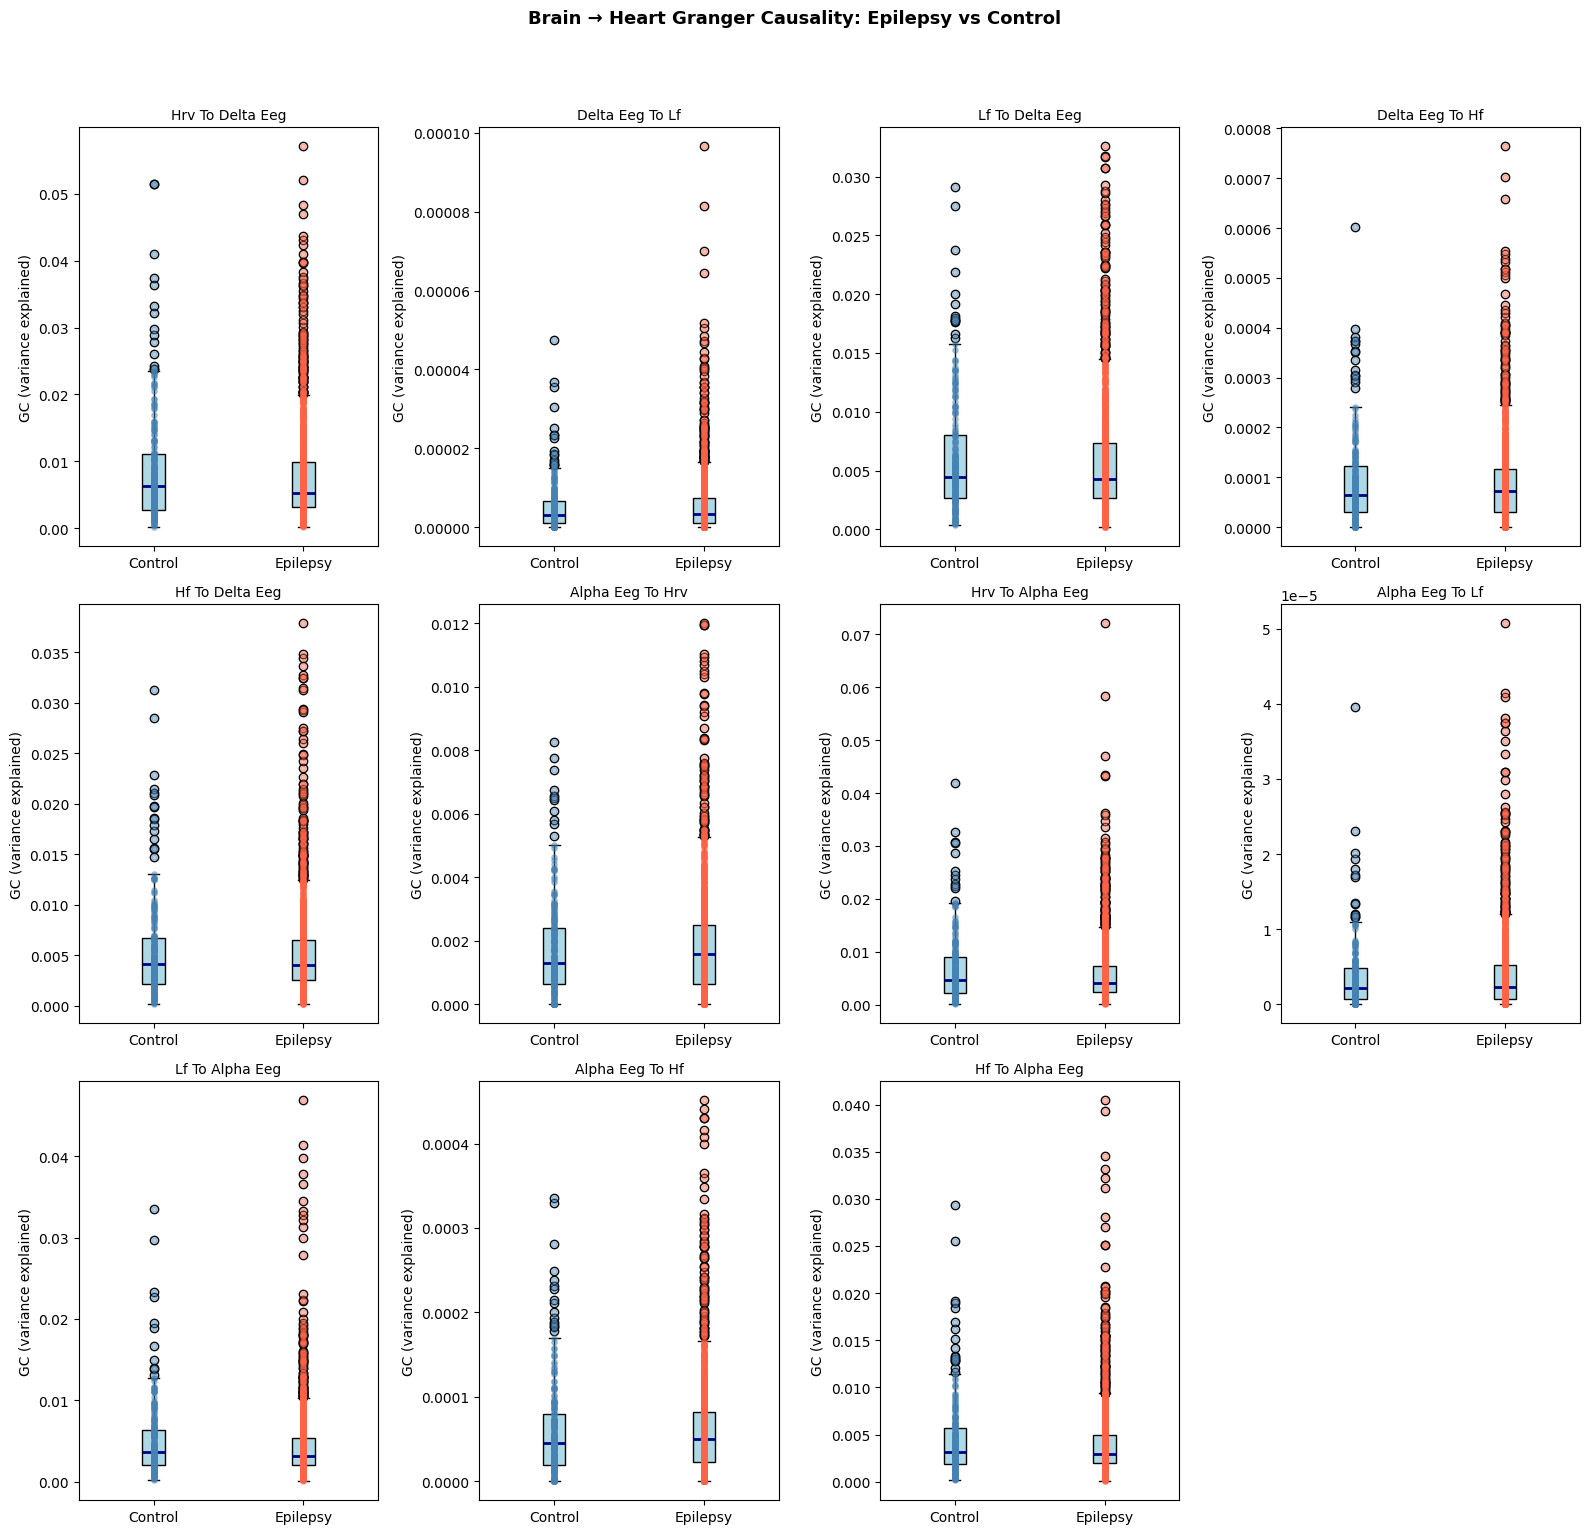

In [30]:
from scipy.stats import zscore

def remove_subject_outliers(epilepsy_flat, control_flat, threshold=3.5):
    """
    Remove subjects whose GC values are extreme outliers
    across any measure.
    """
    measures = list(epilepsy_flat[0].keys())
    all_flat  = epilepsy_flat + control_flat
    
    # Compute z-scores across all subjects for each measure
    keep_epi  = [True] * len(epilepsy_flat)
    keep_ctrl = [True] * len(control_flat)
    
    for measure in measures:
        all_vals = np.array([s[measure] for s in all_flat])
        zscores  = np.abs(zscore(all_vals))
        
        for i in range(len(epilepsy_flat)):
            if zscores[i] > threshold:
                keep_epi[i] = False
                
        for i in range(len(control_flat)):
            if zscores[len(epilepsy_flat) + i] > threshold:
                keep_ctrl[i] = False
    
    epi_clean  = [s for s, k in zip(epilepsy_flat, keep_epi)  if k]
    ctrl_clean = [s for s, k in zip(control_flat, keep_ctrl) if k]
    
    print(f"Removed {sum(~np.array(keep_epi))} epilepsy outliers, "
          f"{sum(~np.array(keep_ctrl))} control outliers")
    print(f"Remaining: {len(epi_clean)} epilepsy, {len(ctrl_clean)} control")
    
    return epi_clean, ctrl_clean


# Apply before stats
epi_clean, ctrl_clean = remove_subject_outliers(epilepsy_flat, control_flat)
comparison_results = compare_groups(epi_clean, ctrl_clean)
plot_group_comparison(comparison_results)

C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, epi],
C:\Users\student\AppData\Local\Temp\ipykernel_6388\2155067464.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old 

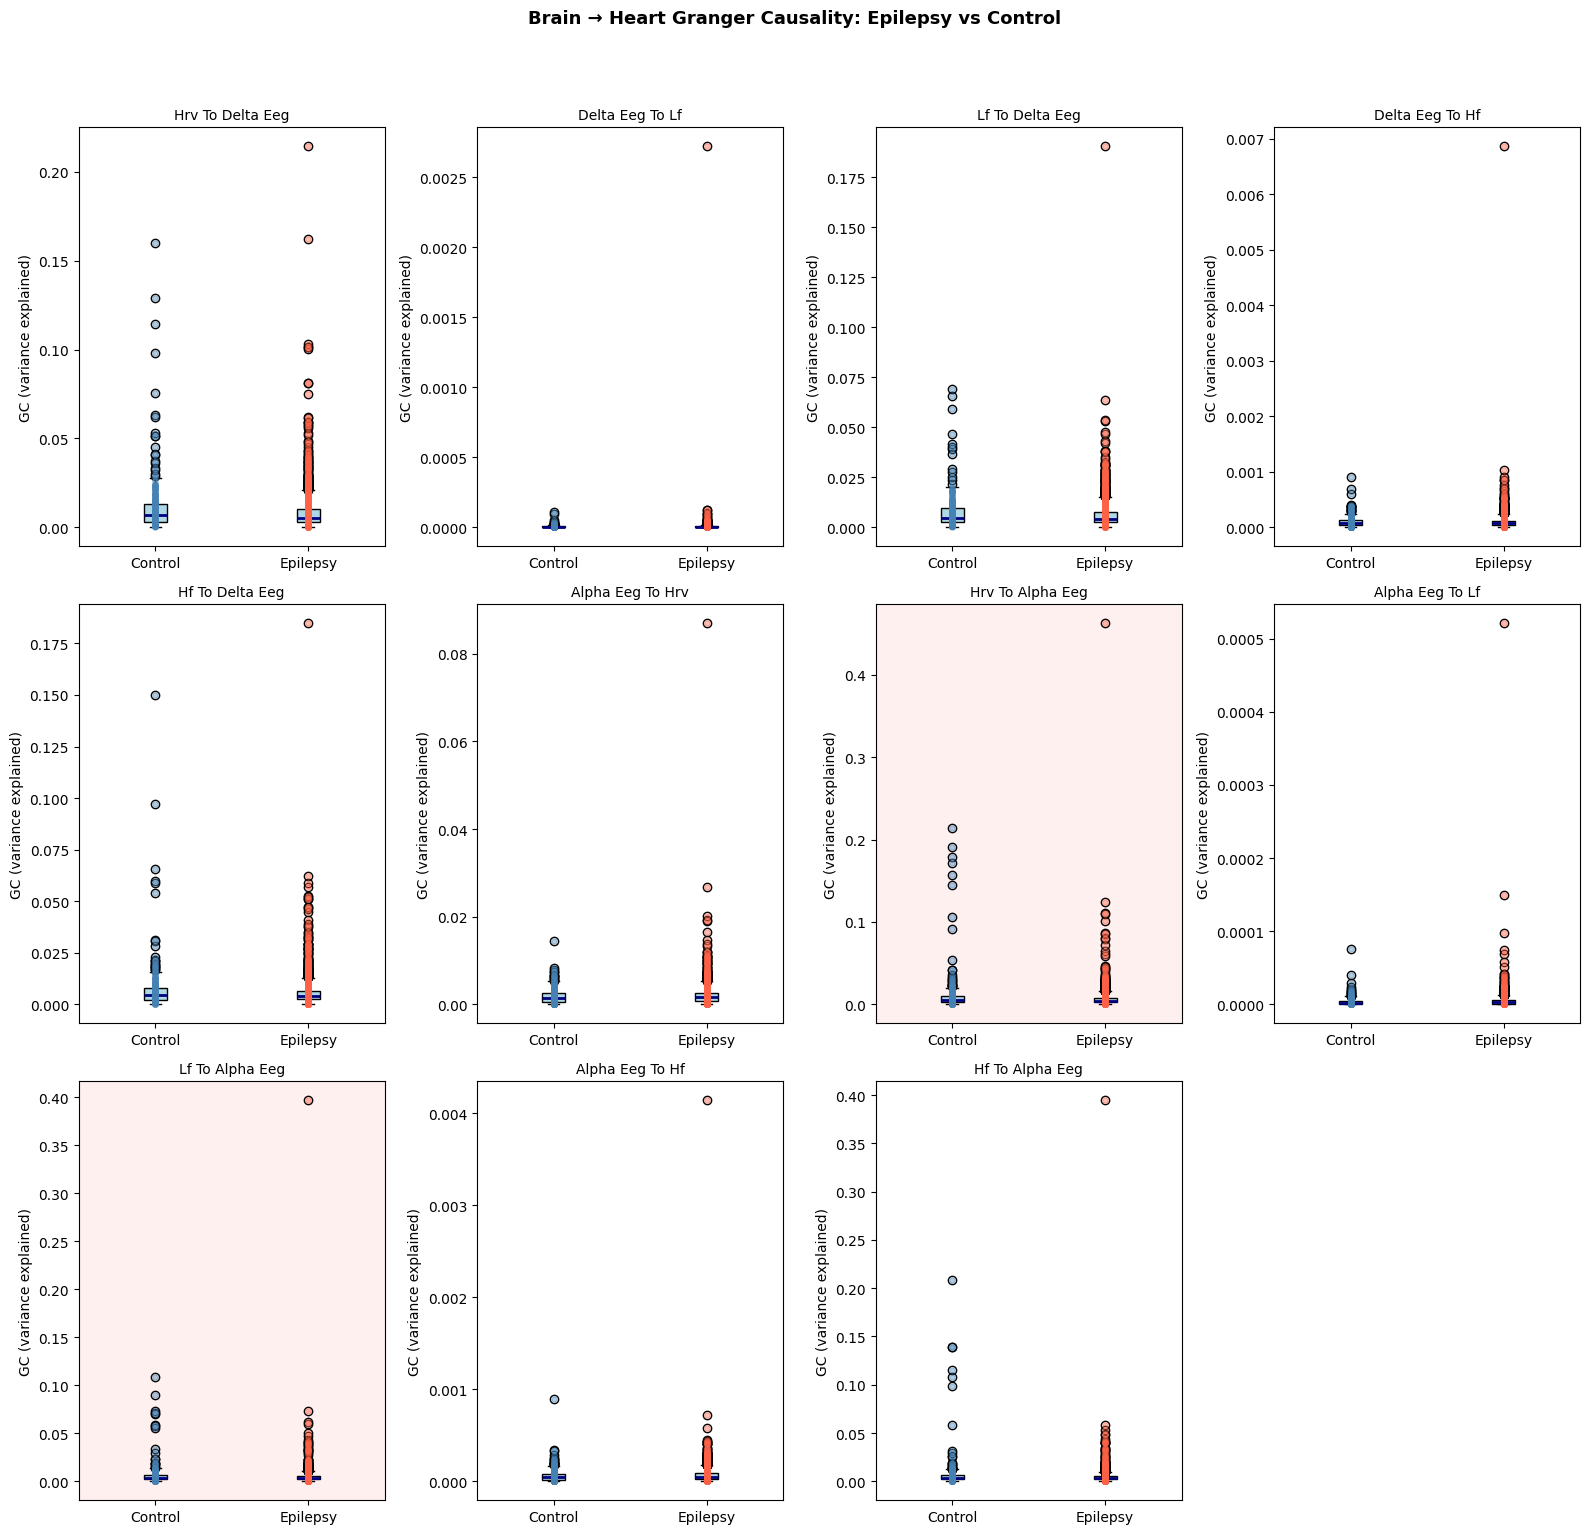

In [31]:
comparison_results = compare_groups(epilepsy_flat, control_flat)

plot_group_comparison(comparison_results)

In [ ]:
def results_table(comparison_results):
    rows = []
    for measure, vals in comparison_results.items():
        rows.append({
            'Measure'         : measure.replace('_', ' ').title(),
            'Control (median)': f"{np.median(vals['control']):.4f}",
            'Epilepsy (median)': f"{np.median(vals['epilepsy']):.4f}",
            'U statistic'     : f"{vals['U']:.1f}",
            'p-value'         : f"{vals['p']:.4f}",
            'Significant'     : '✓' if vals['p'] < 0.05 else '✗'
        })
    
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    df.to_csv('gc_results.csv', index=False)
    return df

results_table(comparison_results)

         Measure Control (median) Epilepsy (median) U statistic p-value Significant
       Optimal P          19.0000           19.0000         0.5  0.6188           ✗
Delta Eeg To Hrv           0.0000            0.0000         0.3  0.7326           ✗
Delta Hrv To Eeg           0.0000            0.0000         2.3  0.0245           ✓
 Delta Eeg To Lf           0.0000            0.0000        -2.0  0.0408           ✓
 Lf To Delta Eeg           0.0000            0.0000         1.9  0.0527           ✗
 Delta Eeg To Hf           0.0000            0.0000        -0.8  0.4000           ✗
 Hf To Delta Eeg           0.0000            0.0000         2.3  0.0202           ✓
Alpha Eeg To Hrv           0.0000            0.0000         0.8  0.4179           ✗
Alpha Hrv To Eeg           0.0000            0.0000        -0.1  0.9003           ✗
 Alpha Eeg To Lf           0.0000            0.0000        -0.4  0.6697           ✗
 Lf To Alpha Eeg           0.0000            0.0000         1.7  0.0978     

,Measure,Control (median),Epilepsy (median),U statistic,p-value,Significant
0,Optimal P,19.0000,19.0000,0.5,0.6188,✗
1,Delta Eeg To Hrv,0.0000,0.0000,0.3,0.7326,✗
2,Delta Hrv To Eeg,0.0000,0.0000,2.3,0.0245,✓
3,Delta Eeg To Lf,0.0000,0.0000,-2.0,0.0408,✓
4,Lf To Delta Eeg,0.0000,0.0000,1.9,0.0527,✗
5,Delta Eeg To Hf,0.0000,0.0000,-0.8,0.4000,✗
6,Hf To Delta Eeg,0.0000,0.0000,2.3,0.0202,✓
7,Alpha Eeg To Hrv,0.0000,0.0000,0.8,0.4179,✗
8,Alpha Hrv To Eeg,0.0000,0.0000,-0.1,0.9003,✗
9,Alpha Eeg To Lf,0.0000,0.0000,-0.4,0.6697,✗


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have age in your metadata
epi_ages  = [d.description['age'] for d in tuh_bhi.datasets 
             if d.description['target'] == 1]
ctrl_ages = [d.description['age'] for d in tuh_bhi.datasets 
             if d.description['target'] == 0]

print(f"Epilepsy age: mean={np.mean(epi_ages):.1f}, "
      f"std={np.std(epi_ages):.1f}, "
      f"range={min(epi_ages):.0f}-{max(epi_ages):.0f}")
print(f"Control age:  mean={np.mean(ctrl_ages):.1f}, "
      f"std={np.std(ctrl_ages):.1f}, "
      f"range={min(ctrl_ages):.0f}-{max(ctrl_ages):.0f}")

# Plot age distributions
plt.figure(figsize=(8, 4))
plt.hist(ctrl_ages, bins=20, alpha=0.6, label='Control',  color='steelblue')
plt.hist(epi_ages,  bins=20, alpha=0.6, label='Epilepsy', color='tomato')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age distribution by group')
plt.legend()
plt.show()

# Test if age differs between groups
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(epi_ages, ctrl_ages, alternative='two-sided')
print(f"\nAge difference between groups: p={p:.4f}")
print("Groups are age-matched" if p > 0.05 else 
      "WARNING: groups differ significantly in age — confound!")

KeyError: 'age'

HRV std: 0.084196
LF std:  0.023467
HF std:  0.013371


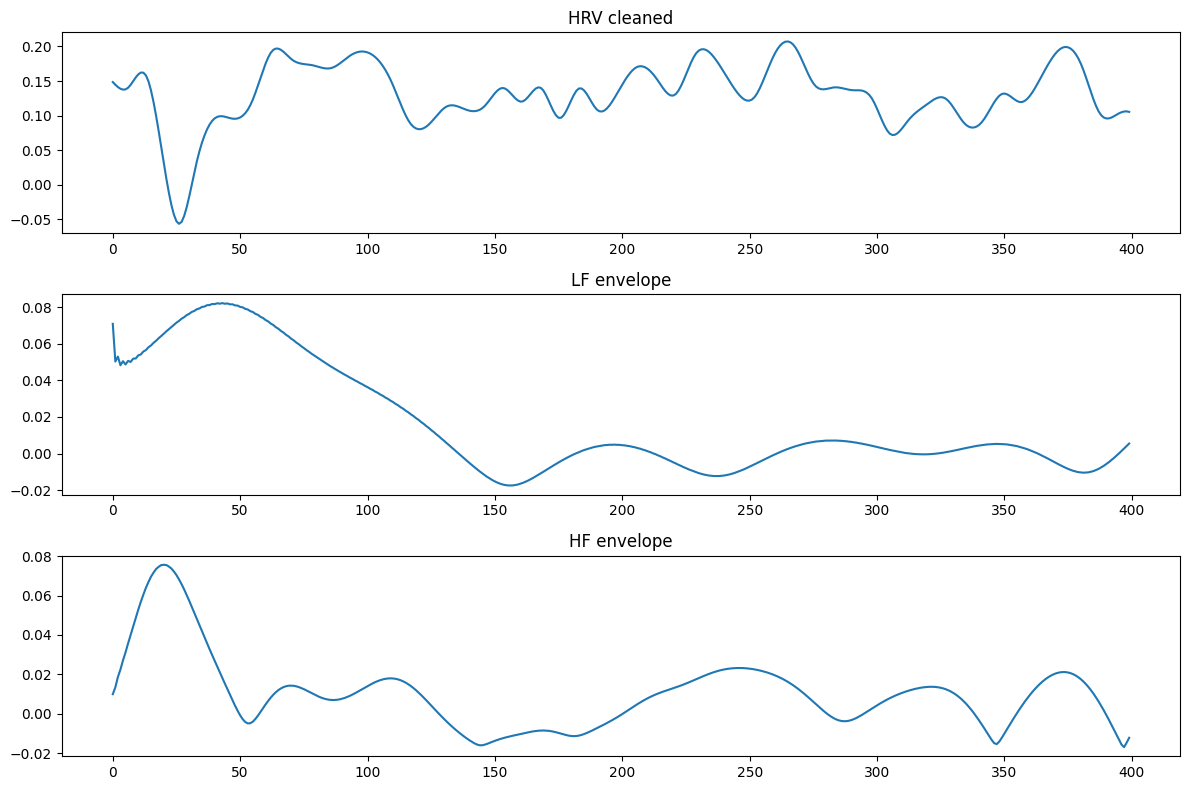

  Removed 2469 artifact samples (1.0%)
delta_eeg_to_hrv: 3.1046e-04  |  hrv_to_delta_eeg: 1.6488e-02
delta_eeg_to_lf: 4.4355e-06  |  lf_to_delta_eeg: 4.0045e-03
delta_eeg_to_hf: 1.8001e-04  |  hf_to_delta_eeg: 3.0354e-03


In [ ]:
d = tuh_bhi.datasets[0]
hrv = np.array(get_HRV(detect_R_peaks(d))).flatten()
hrv_8hz   = resample_to(hrv, 25, 8)
hrv_clean = preprocess_hrv(hrv_8hz)
lf, hf    = compute_hrv_bands(hrv_clean, 8)

print(f"HRV std: {hrv_clean.std():.6f}")
print(f"LF std:  {lf.std():.6f}")
print(f"HF std:  {hf.std():.6f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(hrv_clean[:400]); axes[0].set_title('HRV cleaned')
axes[1].plot(lf[:400]);        axes[1].set_title('LF envelope')
axes[2].plot(hf[:400]);        axes[2].set_title('HF envelope')
plt.tight_layout()
plt.show()

# Also verify GC direction on one subject
idx = d.raw.ch_names.index('T3')
delta_env   = mean_band_envelope(d.raw.get_data(), [idx], 256, 0.5, 4.0)
delta_clean = clean_envelope(delta_env)
delta_8hz   = resample_to(delta_clean, 256, 8)

min_len = min(len(hrv_clean), len(delta_8hz), len(lf), len(hf))

def norm(x):
    return (x - x.mean()) / (x.std() + 1e-12)

hrv_n   = norm(hrv_clean[:min_len])
delta_n = norm(delta_8hz[:min_len])
lf_n    = norm(lf[:min_len])
hf_n    = norm(hf[:min_len])

p_opt, _ = select_var_order(np.array([hrv_n, delta_n]), 20, tau=5, criterion='bic')

for target_name, target_n in [('hrv', hrv_n), ('lf', lf_n), ('hf', hf_n)]:
    seg = np.array([target_n, delta_n])
    gc_fwd = compute_gc(seg, target_idx=0, source_indices=[1], p=p_opt, tau=5)
    gc_rev = compute_gc(seg, target_idx=1, source_indices=[0], p=p_opt, tau=5)
    print(f"delta_eeg_to_{target_name}: {gc_fwd:.4e}  |  "
          f"{target_name}_to_delta_eeg: {gc_rev:.4e}")

## Test

In [ ]:
# Run this on one subject to inspect the actual signals
d = tuh_bhi.datasets[0]
eeg_data = d.raw.get_data()
ch_names = d.raw.ch_names
rpeaks = detect_R_peaks(d)
hrv = np.array(get_HRV(rpeaks)).flatten()

# Check what HRV actually looks like
print(f"HRV length: {len(hrv)}")
print(f"HRV min/max: {hrv.min():.4f} / {hrv.max():.4f}")
print(f"HRV mean: {hrv.mean():.4f}")
print(f"HRV std: {hrv.std():.4f}")

# Check EEG envelope
from scipy.signal import butter, filtfilt
from scipy.signal import hilbert

idx = ch_names.index('T3')
signal = eeg_data[idx]
print(f"\nRaw EEG min/max: {signal.min():.6f} / {signal.max():.6f}")

nyq = 256 / 2
b, a = butter(4, [0.5/nyq, 4.0/nyq], btype='band')
filtered = filtfilt(b, a, signal)
envelope = np.abs(hilbert(filtered))
print(f"Delta envelope min/max: {envelope.min():.6f} / {envelope.max():.6f}")
print(f"Delta envelope mean: {envelope.mean():.6f}")

# After resampling
delta_rs = resample_to(envelope, 256, 25)
print(f"\nResampled delta length: {len(delta_rs)}")
print(f"HRV length: {len(hrv)}")

# Check what get_HRV returns — is it in ms, seconds, or bpm?
print(f"\nFirst 10 HRV values: {hrv[:10]}")

HRV length: 23180
HRV min/max: 0.5742 / 1.1201
HRV mean: 0.8880
HRV std: 0.0994

Raw EEG min/max: -143.098297 / 73.631523
Delta envelope min/max: 0.001226 / 40.317964
Delta envelope mean: 4.280834

Resampled delta length: 23211
HRV length: 23180

First 10 HRV values: [0.57421875 0.61965554 0.66253684 0.70292624 0.74088736 0.77648379
 0.80977913 0.84083699 0.86972096 0.89649464]


In [ ]:
lf, hf = compute_hrv_bands(hrv, 25)

print(f"HRV mean: {hrv.mean():.4f}")
print(f"LF envelope mean: {lf.mean():.6f}")
print(f"HF envelope mean: {hf.mean():.6f}")

# Should all be on similar order of magnitude, e.g.
# HRV mean: 0.888
# LF mean:  0.002 - 0.010
# HF mean:  0.001 - 0.005

HRV mean: 0.8880
LF envelope mean: 0.043502
HF envelope mean: 0.020789
